Linear Discriminant Analysis (LDA) is a classification technique due to Fisher that dates
back to the 1930’s
It can be seen as a different approximation to the Bayes Optimal Classifier for
real-valued data.
It is a classification method built from Bayes’ rule.

The goal is:

P(Y=c∣X=x)

where x may be a vector of features.

LDA makes one key assumption:

Each class produces data from a Gaussian distribution, and all classes share the same covariance matrix.

So for each class c:

X∣Y=c∼N(μc,Σ)

where:

μc = mean feature vector for class c
Σ = shared covariance matrix

πc=P(Y=c)

The model asks:

Which class makes this observed point x most likely?


an object belongs to class 1 or 0.



In [1]:
import numpy as np

x1 = np.array([2,   4,  6,  8, 10, 12, 14, 16, 18, 20])
x0 = np.array([12, 14, 16, 18, 20, 22, 24, 26, 28, 30])



x1_mean = np.mean(x1)
x0_mean = np.mean(x0)

x1_var = np.var(x1)
x0_var = np.var(x0)


observation =  21

dist_from_1 = observation - x1_mean
dist_from_0 = observation - x0_mean

if dist_from_1 < dist_from_0:
    print("The observation is class 1")
    
else:
    print("The observation is class 0")



The observation is class 0


In the one-dimensional case, LDA creates a cutoff point at the mean of the 2 means.

With equal priors and equal variance, the cutoff is halfway between the means:

In one dimension, the boundary is a point.
In two dimensions, it is a line.
In three dimensions, it is a plane.

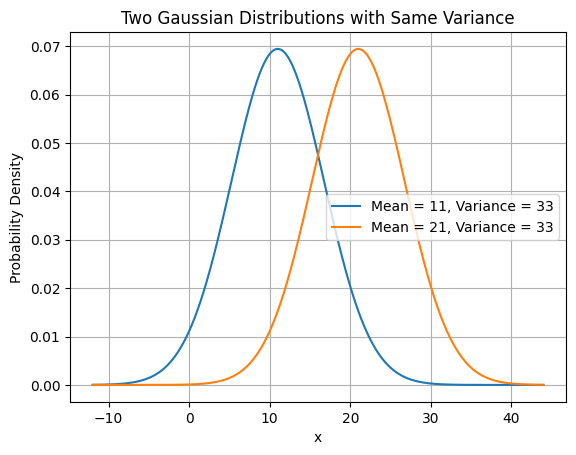

In [2]:
import matplotlib.pyplot as plt

assert x1_var == x0_var, "Variances must be the same for both distributions"
std_dev = np.sqrt(x1_var)

# X values covering both distributions
x = np.linspace(x1_mean - 4*std_dev, x0_mean + 4*std_dev, 1000)

# Gaussian PDF formula
y1 = (1 / (std_dev * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x - x1_mean) / std_dev) ** 2)
y2 = (1 / (std_dev * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x - x0_mean) / std_dev) ** 2)

# Plot both
plt.plot(x, y1, label="Mean = 11, Variance = 33")
plt.plot(x, y2, label="Mean = 21, Variance = 33")

plt.xlabel("x")
plt.ylabel("Probability Density")
plt.title("Two Gaussian Distributions with Same Variance")
plt.legend()
plt.grid(True)

plt.show()